<a href="https://colab.research.google.com/github/vitriadwiernita/VITRIA-DWI-ERNITA/blob/main/CODINGAN_UAS_STOKASTIK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAMA : VITRIA DWI ERNITA**

**NIM : 2430109040001**

**MATA KULIAH : PENGANTAR PROSES STOKASTIK**


---

# **PROYEK EAS PENGANTAR PROSES STOKASTIK**


---

# ***- Analisis Perpindahan Status Pelanggan Online Shop Menggunakan Rantai Markov -***



---
**IDE KASUS**


Sistem yang dipilih:
Rantai Markov (Markov Chain)

`Studi Kasus`

Menganalisis perpindahan status pelanggan pada sebuah online shop.

Status pelanggan:

*   Visitor
*   Customer
*   Loyal Customer
*   Churn

Kasus ini sangat cocok untuk proses stokastik karena:

* Perubahan status pelanggan bersifat probabilistik
* Status masa depan dipengaruhi status saat ini
* Cocok dimodelkan menggunakan Markov Chain
* Ada simulasi dan prediksi perilaku pelanggan
* Bisa dipakai untuk rekomendasi strategi bisnis


**TUJUAN PROYEK**
1. Menganalisis perpindahan status pelanggan
2. Membentuk matriks probabilitas transisi
3. Melakukan simulasi perilaku pelanggan
4. Menghitung steady state
5. Memberikan rekomendasi bisnis berdasarkan hasil analisis

**ALUR ANALISIS**
1. Membuat data status pelanggan
2. Menghitung transisi antar status
3. Membentuk matriks probabilitas
4. Simulasi Markov Chain
5. Menghitung steady state
6. Visualisasi hasil
7. Analisis bisnis

# **CODINGAN**

=== DATA STATUS PELANGGAN ===
     Status
0   Visitor
1  Customer
2  Customer
3     Loyal
4     Loyal

=== MISSING VALUE ===
Status    0
dtype: int64

=== JUMLAH TRANSISI ===
          Visitor  Customer  Loyal  Churn
Visitor       0.0      11.0    0.0    0.0
Customer      5.0       4.0   11.0    2.0
Loyal         1.0       7.0    6.0    3.0
Churn         5.0       0.0    0.0    0.0


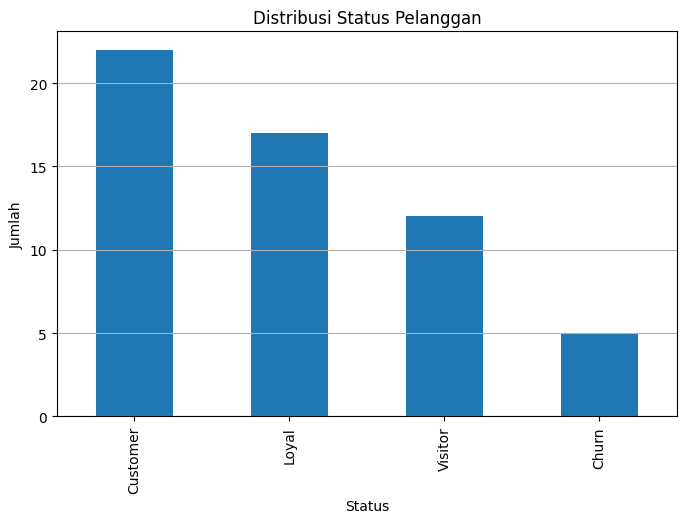


=== MATRIKS PROBABILITAS TRANSISI ===
           Visitor  Customer     Loyal     Churn
Visitor   0.000000  1.000000  0.000000  0.000000
Customer  0.227273  0.181818  0.500000  0.090909
Loyal     0.058824  0.411765  0.352941  0.176471
Churn     1.000000  0.000000  0.000000  0.000000


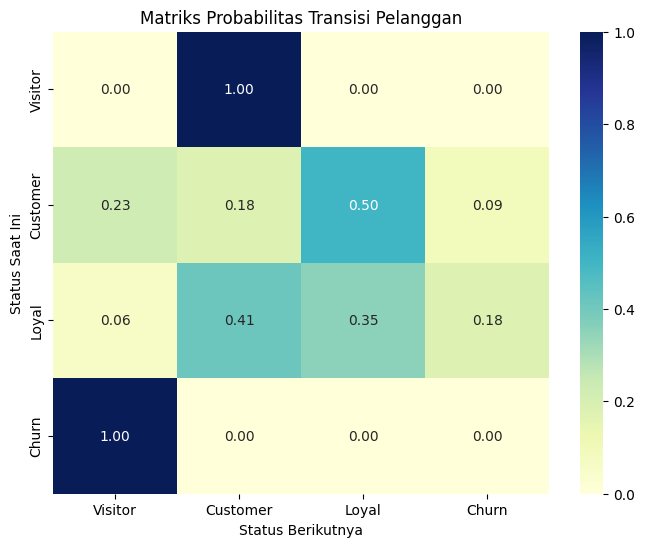


Interpretasi Matriks Transisi:
Setiap baris menunjukkan probabilitas perpindahan dari state saat ini
ke state berikutnya.
Jumlah probabilitas pada setiap baris = 1

=== HASIL SIMULASI MARKOV CHAIN ===
['Visitor', np.str_('Customer'), np.str_('Churn'), np.str_('Visitor'), np.str_('Customer'), np.str_('Visitor'), np.str_('Customer'), np.str_('Visitor'), np.str_('Customer'), np.str_('Loyal'), np.str_('Loyal'), np.str_('Visitor'), np.str_('Customer'), np.str_('Loyal'), np.str_('Customer'), np.str_('Visitor'), np.str_('Customer'), np.str_('Customer'), np.str_('Loyal'), np.str_('Customer'), np.str_('Customer')]


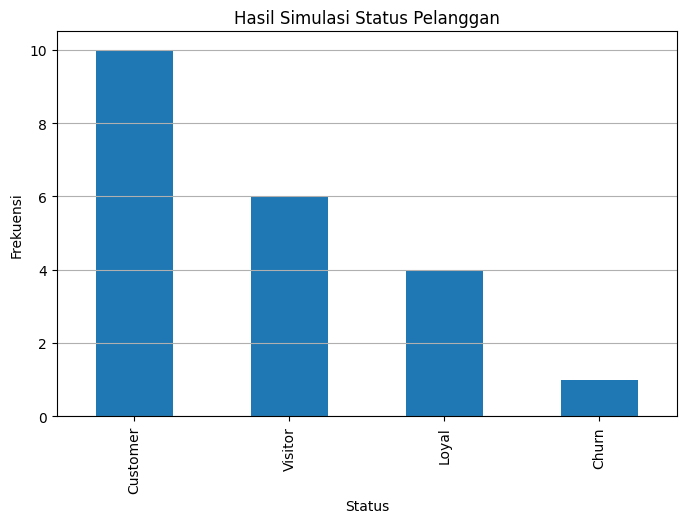

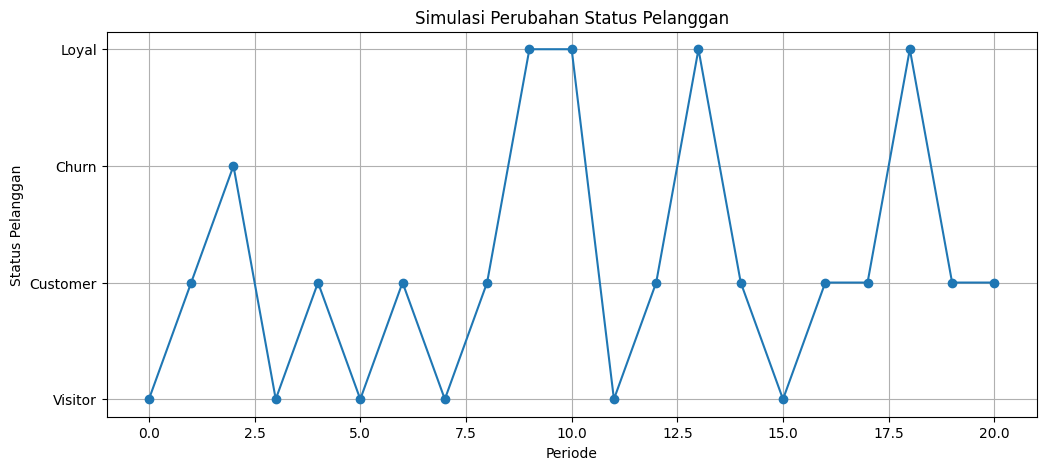


=== STEADY STATE ===
Visitor : 0.2
Customer : 0.4
Loyal : 0.3091
Churn : 0.0909

INTERPRETASI STEADY STATE
Steady state menunjukkan kondisi jangka panjang sistem.
Probabilitas terbesar menunjukkan state yang paling dominan
dalam jangka panjang.

State dominan jangka panjang: Customer

=== DISTRIBUSI STATUS PELANGGAN ===
Customer    10
Visitor      6
Loyal        4
Churn        1
Name: count, dtype: int64


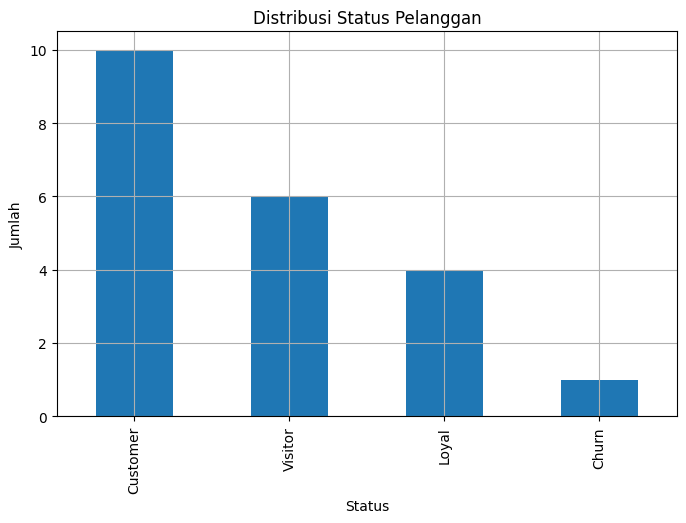


Validasi jumlah probabilitas setiap baris:
Visitor     1.0
Customer    1.0
Loyal       1.0
Churn       1.0
dtype: float64

=== ANALISIS HASIL ===
Pelanggan loyal memiliki probabilitas tinggi.
Online shop disarankan meningkatkan program membership.
Risiko kehilangan pelanggan relatif rendah.

REKOMENDASI
1. Meningkatkan promosi untuk mengubah Visitor menjadi Customer
2. Memberikan program loyalitas agar Customer menjadi Loyal Customer
3. Memberikan diskon atau voucher untuk mengurangi pelanggan Churn
4. Mempertahankan pelanggan loyal dengan pelayanan yang baik

=== KESIMPULAN ===
Rantai Markov dapat digunakan untuk memodelkan
perpindahan status pelanggan pada online shop.
Model ini membantu perusahaan memahami
perilaku pelanggan dan menyusun strategi bisnis.


In [ ]:
# ============================================================
# PROYEK UAS PENGANTAR PROSES STOKASTIK
# IMPLEMENTASI RANTAI MARKOV WAKTU DISKRIT
# PADA ANALISIS STATUS PELANGGAN ONLINE SHOP
# ============================================================

# ============================================================
# IMPORT LIBRARY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# DATA UNDERSTANDING
# ============================================================

# State pelanggan:
# 1. Visitor  : hanya melihat produk
# 2. Customer : pernah melakukan pembelian
# 3. Loyal    : sering melakukan pembelian
# 4. Churn    : berhenti menggunakan layanan

# DATA UNDERSTANDING

# Pada proyek ini digunakan data simulasi perilaku pelanggan online shop.
# Data dibuat berdasarkan pola umum perpindahan pelanggan pada sistem e-commerce.

# Setiap pelanggan dapat berada pada salah satu state berikut:

# 1. Visitor
#   Pelanggan hanya melihat produk tanpa melakukan transaksi.

# 2. Customer
#   Pelanggan pernah melakukan pembelian.

# 3. Loyal Customer
#   Pelanggan melakukan pembelian berulang.

# 4. Churn
#   Pelanggan berhenti menggunakan layanan.

# Data simulasi digunakan untuk memodelkan probabilitas perpindahan status pelanggan menggunakan Rantai Markov waktu diskrit.

# Dataset simulasi status pelanggan
customer_data = [
    'Visitor','Customer','Customer','Loyal','Loyal','Customer','Visitor','Customer',
    'Loyal','Loyal','Churn','Visitor','Customer','Loyal','Customer','Visitor',
    'Customer','Customer','Loyal','Loyal','Customer','Churn','Visitor','Customer',
    'Loyal','Loyal','Customer','Visitor','Customer','Loyal','Churn','Visitor',
    'Customer','Customer','Loyal','Customer','Visitor','Customer','Loyal','Loyal',
    'Customer','Visitor','Customer','Loyal','Churn','Visitor','Customer','Loyal',
    'Customer','Customer','Loyal','Loyal','Visitor','Customer','Churn','Visitor'
]

# Mengubah menjadi DataFrame
customer_df = pd.DataFrame({
    'Status': customer_data
})

print("=== DATA STATUS PELANGGAN ===")
print(customer_df.head())

# ============================================================
# PRE-PROCESSING DATA
# ============================================================

# Mengecek missing value
print("\n=== MISSING VALUE ===")
print(customer_df.isnull().sum())

# Daftar state
states = ['Visitor', 'Customer', 'Loyal', 'Churn']


# TEORI RANTAI MARKOV

# Rantai Markov adalah proses stokastik yang menggambarkan perpindahan suatu sistem dari satu state ke state lainnya.

# Pada model Markov, probabilitas keadaan di masa depan hanya dipengaruhi oleh keadaan saat ini dan tidak dipengaruhi oleh keadaan sebelumnya.

# Matriks probabilitas transisi dinyatakan sebagai:

#    P = [pij]

# Dimana:
# - pij adalah probabilitas perpindahan dari state i ke state j
# - jumlah probabilitas pada setiap baris bernilai 1

# Model ini digunakan untuk menganalisis pola perpindahan pelanggan online shop dari waktu ke waktu.

# ============================================================
# MEMBENTUK MATRIKS TRANSISI
# ============================================================

# Membuat matriks kosong
transition_counts = pd.DataFrame(
    np.zeros((len(states), len(states))),
    index=states,
    columns=states
)

# Menghitung perpindahan antar state
for i in range(len(customer_data) - 1):

    current_state = customer_data[i]
    next_state = customer_data[i + 1]

    transition_counts.loc[current_state, next_state] += 1

print("\n=== JUMLAH TRANSISI ===")
print(transition_counts)

# ============================================================
# VISUALISASI DISTRIBUSI STATUS PELANGGAN
# ============================================================

plt.figure(figsize=(8,5))
pd.Series(customer_data).value_counts().plot(kind='bar')
plt.title('Distribusi Status Pelanggan')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.grid(axis='y')
plt.show()

# ============================================================
# MENGHITUNG PROBABILITAS TRANSISI
# ============================================================

transition_matrix = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

print("\n=== MATRIKS PROBABILITAS TRANSISI ===")
print(transition_matrix)

# ============================================================
# VISUALISASI MATRIKS TRANSISI
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
)

plt.title('Matriks Probabilitas Transisi Pelanggan')
plt.xlabel('Status Berikutnya')
plt.ylabel('Status Saat Ini')

plt.show()

print("\nInterpretasi Matriks Transisi:")
print("Setiap baris menunjukkan probabilitas perpindahan dari state saat ini")
print("ke state berikutnya.")
print("Jumlah probabilitas pada setiap baris = 1")

# ============================================================
# SIMULASI MARKOV CHAIN
# ============================================================

np.random.seed(42)

# Status awal
current_state = 'Visitor'

# Menyimpan hasil simulasi
future_states = [current_state]

# Simulasi 20 periode
for i in range(20):

    # Mengambil probabilitas berdasarkan state sekarang
    probabilities = transition_matrix.loc[current_state].values

    # Menentukan state berikutnya
    next_state = np.random.choice(
        states,
        p=probabilities
    )

    # Menyimpan hasil
    future_states.append(next_state)

    # Update state
    current_state = next_state

print("\n=== HASIL SIMULASI MARKOV CHAIN ===")
print(future_states)

# ============================================================
# VISUALISASI HASIL SIMULASI
# ============================================================

simulation_counts = pd.Series(future_states).value_counts()

plt.figure(figsize=(8,5))
simulation_counts.plot(kind='bar')
plt.title('Hasil Simulasi Status Pelanggan')
plt.xlabel('Status')
plt.ylabel('Frekuensi')
plt.grid(axis='y')
plt.show()

# ============================================================
# VISUALISASI HASIL SIMULASI
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(future_states, marker='o')

plt.title('Simulasi Perubahan Status Pelanggan')
plt.xlabel('Periode')
plt.ylabel('Status Pelanggan')

plt.grid(True)
plt.show()

# ============================================================
# MENGHITUNG STEADY STATE
# ============================================================

P = transition_matrix.values

# Eigen value dan eigen vector
values, vectors = np.linalg.eig(P.T)

# Mengambil eigen vector untuk eigen value = 1
steady_state = vectors[:, np.isclose(values, 1)]

steady_state = steady_state[:, 0]
steady_state = steady_state / steady_state.sum()
steady_state = steady_state.real

print("\n=== STEADY STATE ===")

for i in range(len(states)):
    print(states[i], ':', round(steady_state[i], 4))

print("\nINTERPRETASI STEADY STATE")
print("Steady state menunjukkan kondisi jangka panjang sistem.")
print("Probabilitas terbesar menunjukkan state yang paling dominan")
print("dalam jangka panjang.")

max_state = states[np.argmax(steady_state)]
print(f"\nState dominan jangka panjang: {max_state}")

# ============================================================
# ANALISIS DISTRIBUSI STATUS
# ============================================================

state_counts = pd.Series(future_states).value_counts()

print("\n=== DISTRIBUSI STATUS PELANGGAN ===")
print(state_counts)

# ============================================================
# VISUALISASI DISTRIBUSI STATUS
# ============================================================

plt.figure(figsize=(8, 5))

state_counts.plot(kind='bar')

plt.title('Distribusi Status Pelanggan')
plt.xlabel('Status')
plt.ylabel('Jumlah')

plt.grid(True)
plt.show()

# ============================================================
# VALIDASI JUMLAH PROBABILITAS
# ============================================================

print("\nValidasi jumlah probabilitas setiap baris:")
print(transition_matrix.sum(axis=1))

# ============================================================
# ANALISIS DAN REKOMENDASI
# ============================================================

print("\n=== ANALISIS HASIL ===")

if steady_state[2] > 0.30:
    print("Pelanggan loyal memiliki probabilitas tinggi.")
    print("Online shop disarankan meningkatkan program membership.")
else:
    print("Jumlah loyal customer masih rendah.")
    print("Perlu strategi promosi dan peningkatan layanan.")

if steady_state[3] > 0.20:
    print("Probabilitas churn cukup tinggi.")
    print("Perusahaan perlu meningkatkan customer retention.")
else:
    print("Risiko kehilangan pelanggan relatif rendah.")

print("\nREKOMENDASI")
print("1. Meningkatkan promosi untuk mengubah Visitor menjadi Customer")
print("2. Memberikan program loyalitas agar Customer menjadi Loyal Customer")
print("3. Memberikan diskon atau voucher untuk mengurangi pelanggan Churn")
print("4. Mempertahankan pelanggan loyal dengan pelayanan yang baik")

# ============================================================
# KESIMPULAN SEDERHANA
# ============================================================

print("\n=== KESIMPULAN ===")
print("Rantai Markov dapat digunakan untuk memodelkan")
print("perpindahan status pelanggan pada online shop.")
print("Model ini membantu perusahaan memahami")
print("perilaku pelanggan dan menyusun strategi bisnis.")

# KESIMPULAN

Berdasarkan hasil analisis menggunakan Rantai Markov waktu diskrit, dapat diketahui pola perpindahan pelanggan online shop dari satu status ke status lainnya.

Model Markov mampu memberikan gambaran probabilitas transisi pelanggan serta kondisi steady state dalam jangka panjang.

Hasil simulasi menunjukkan bahwa perilaku pelanggan dapat diprediksi menggunakan pendekatan proses stokastik.

Analisis ini dapat membantu online shop dalam menentukan strategi bisnis untuk meningkatkan loyalitas pelanggan dan mengurangi churn.